<a href="https://colab.research.google.com/github/harshita-89/IDS-using-LSTM-Autoencoder/blob/main/IDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# importing all the necessary packages
import tqdm
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, OneHotEncoder
from mpl_toolkits import mplot3d
from tensorflow.keras.layers import Input, Dense, LSTM, TimeDistributed, RepeatVector
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K
from scipy.spatial.distance import euclidean
import random
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, f1_score, precision_score, recall_score, accuracy_score, ConfusionMatrixDisplay

#**1. LOAD DATA**

In [2]:
from google.colab import files
uploaded = files.upload()
train_data = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Drop unwanted column
if 'difficulty' in train_data.columns:
    train_data = train_data.drop('difficulty', axis=1)
    test_df = test_df.drop('difficulty', axis=1)

Saving test.csv to test.csv
Saving train.csv to train.csv


In [3]:
train_data.shape

(125973, 42)

In [4]:
train_data.head(20)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal
5,0,tcp,private,REJ,0,0,0,0,0,0,...,19,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune
6,0,tcp,private,S0,0,0,0,0,0,0,...,9,0.04,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
7,0,tcp,private,S0,0,0,0,0,0,0,...,15,0.06,0.07,0.00,0.00,1.00,1.00,0.00,0.00,neptune
8,0,tcp,remote_job,S0,0,0,0,0,0,0,...,23,0.09,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
9,0,tcp,private,S0,0,0,0,0,0,0,...,13,0.05,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune


In [5]:
df = train_data

In [6]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace(r'[^\w]', '', regex=True)
)

In [7]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


 # **Preprocessing**

In [8]:
print('different types of services: {}'.format(df['service'].unique()))

different types of services: ['ftp_data' 'other' 'private' 'http' 'remote_job' 'name' 'netbios_ns'
 'eco_i' 'mtp' 'telnet' 'finger' 'domain_u' 'supdup' 'uucp_path' 'Z39_50'
 'smtp' 'csnet_ns' 'uucp' 'netbios_dgm' 'urp_i' 'auth' 'domain' 'ftp'
 'bgp' 'ldap' 'ecr_i' 'gopher' 'vmnet' 'systat' 'http_443' 'efs' 'whois'
 'imap4' 'iso_tsap' 'echo' 'klogin' 'link' 'sunrpc' 'login' 'kshell'
 'sql_net' 'time' 'hostnames' 'exec' 'ntp_u' 'discard' 'nntp' 'courier'
 'ctf' 'ssh' 'daytime' 'shell' 'netstat' 'pop_3' 'nnsp' 'IRC' 'pop_2'
 'printer' 'tim_i' 'pm_dump' 'red_i' 'netbios_ssn' 'rje' 'X11' 'urh_i'
 'http_8001' 'aol' 'http_2784' 'tftp_u' 'harvest']


/tmp/ipykernel_3510/3547602662.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(train_data['label']).plot(kind='bar', figsize=(20, 10))


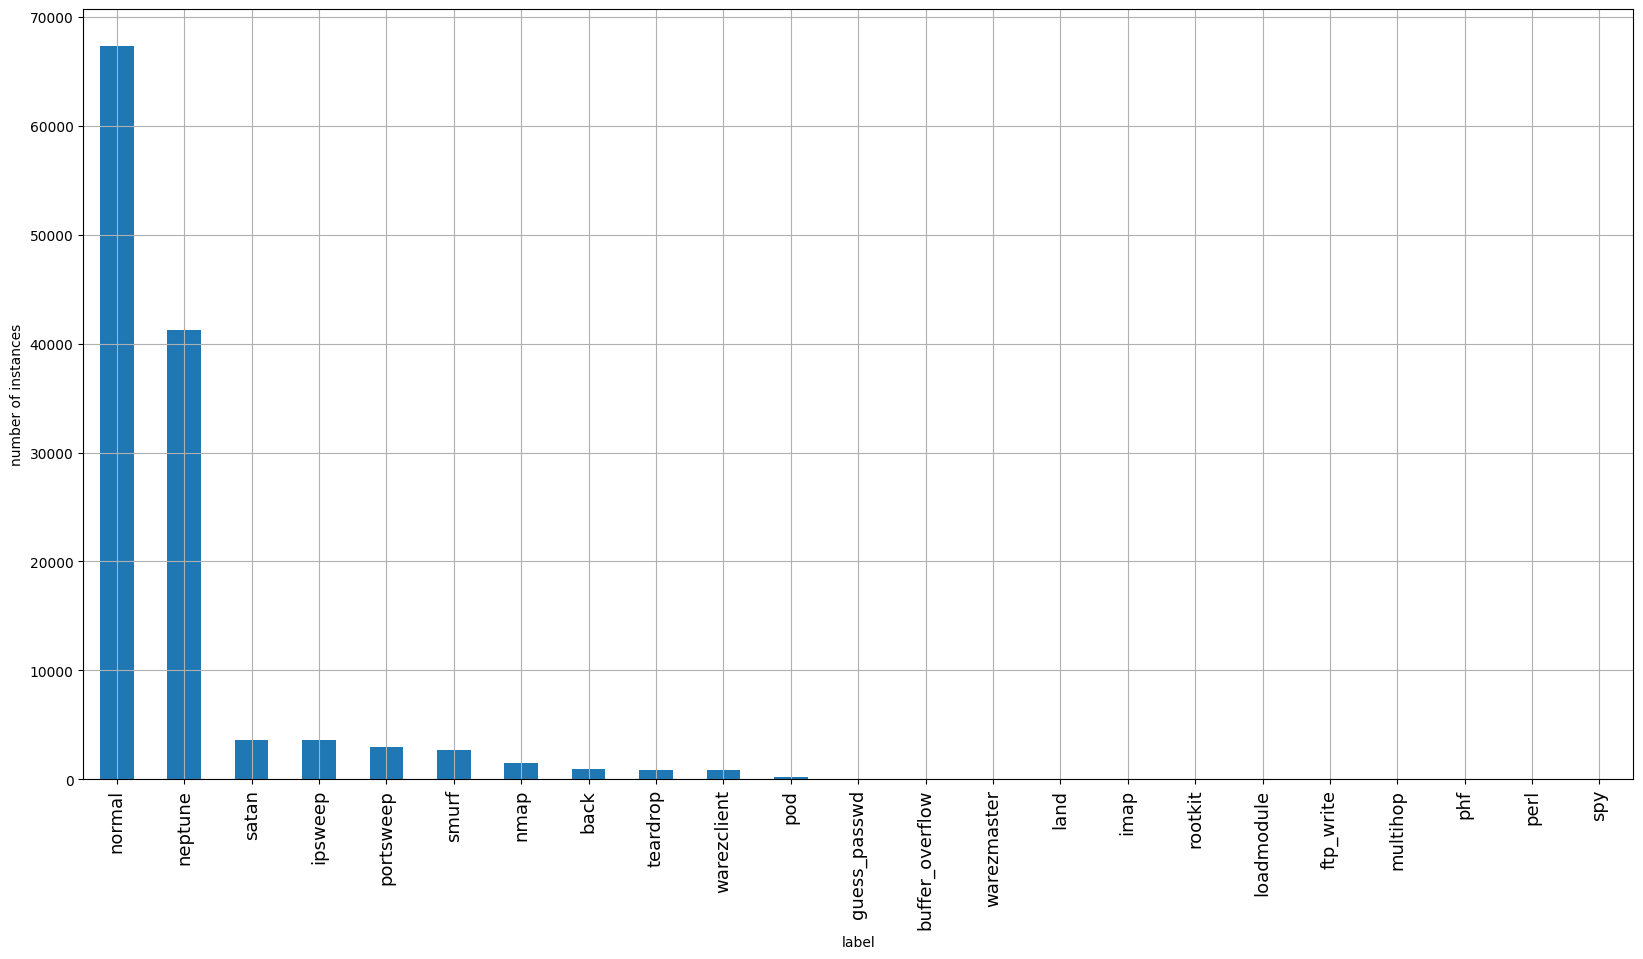

In [9]:
pd.value_counts(train_data['label']).plot(kind='bar', figsize=(20, 10))
plt.ylabel('number of instances')
plt.xticks(fontsize=13)
plt.grid()
plt.show()

In [10]:
# extracting only the rows which have http service.
df_http = df[(df['service']=='http')]

/tmp/ipykernel_3510/1132373792.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df_http['label']).plot(kind='bar', figsize=(20, 10))


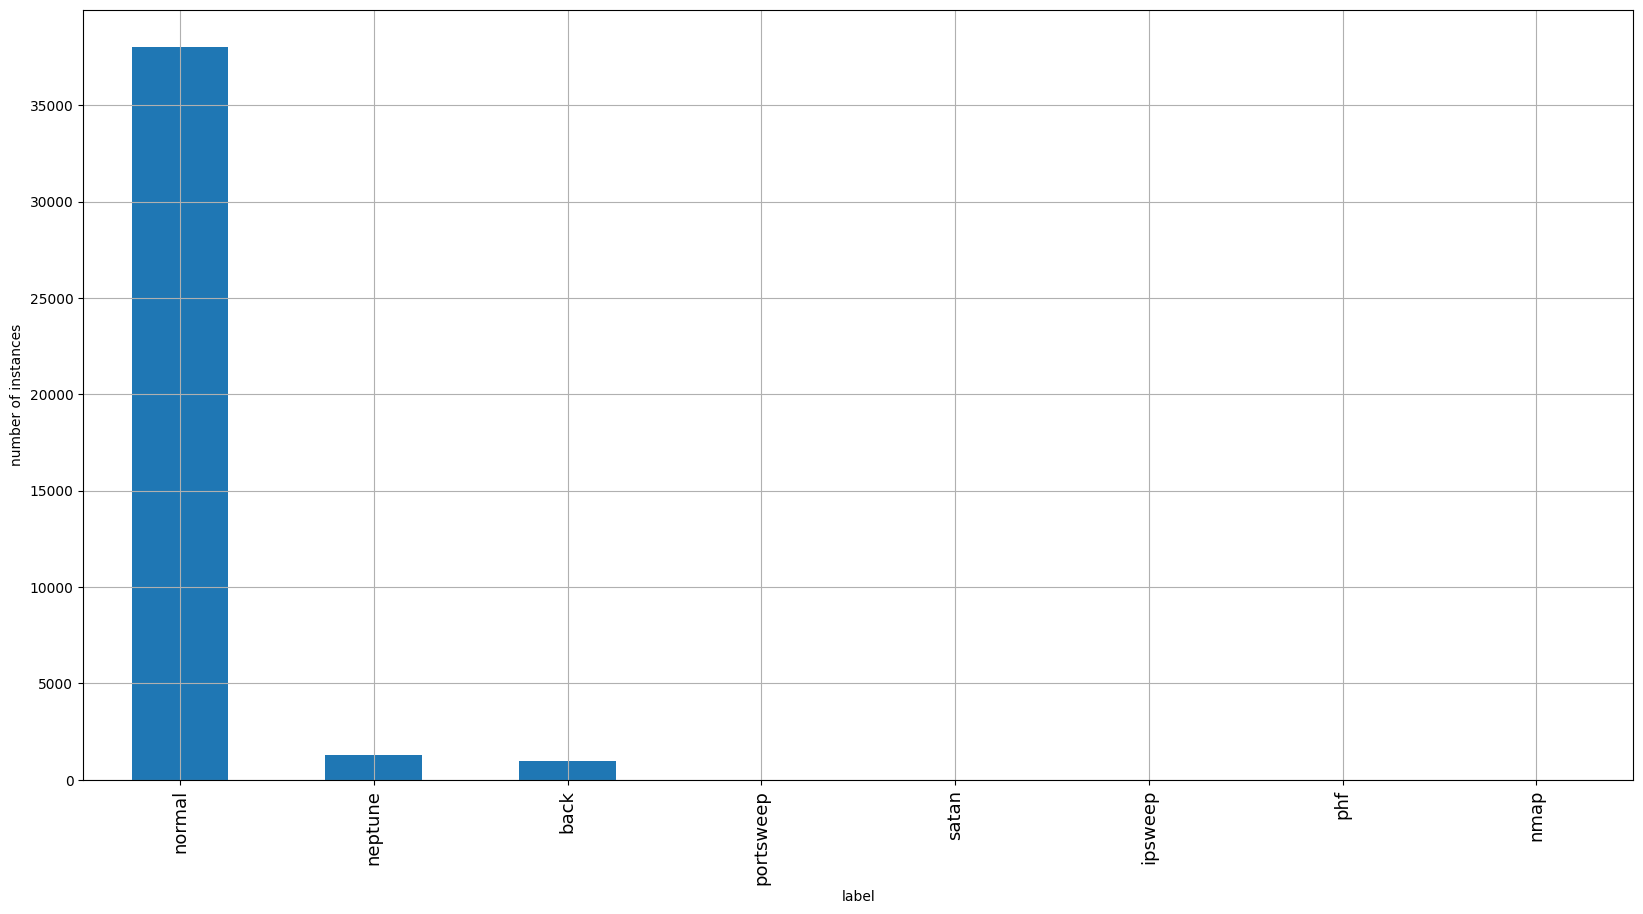

In [11]:
pd.value_counts(df_http['label']).plot(kind='bar', figsize=(20, 10))
plt.ylabel('number of instances')
plt.xticks(fontsize=13)
plt.grid()
plt.show()

In [12]:
normal_instances = df_http[df_http['label']=='normal'].shape[0]
anomalous_instances = df_http[df_http['label']!='normal'].shape[0]
print('number of normal instances = {}'.format(normal_instances))
print('number of anomalous instances = {}'.format(anomalous_instances))

number of normal instances = 38049
number of anomalous instances = 2289


In [13]:
total = normal_instances + anomalous_instances

print('percentage of anomalies = {:.2f}%'.format(
    100 * anomalous_instances / total
))

percentage of anomalies = 5.67%


In [14]:
# extracting only the instances belonging to the normal class
df_http_normal = df_http[df_http['label']=='normal']

In [15]:
df_http_normal.shape

(38049, 42)

In [16]:
# dropping categorical columns
df_http_normal.drop(['protocol_type', 'service', 'flag', 'land', 'logged_in', 'is_host_login', 'is_guest_login', 'label'], axis=1, inplace=True)
# dropping columns with no std deviation
df_http_normal.drop(['wrong_fragment', 'urgent', 'num_failed_logins', 'su_attempted', 'num_file_creations', 'num_outbound_cmds'], axis=1, inplace=True)

/tmp/ipykernel_3510/2078056799.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_http_normal.drop(['protocol_type', 'service', 'flag', 'land', 'logged_in', 'is_host_login', 'is_guest_login', 'label'], axis=1, inplace=True)
/tmp/ipykernel_3510/2078056799.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_http_normal.drop(['wrong_fragment', 'urgent', 'num_failed_logins', 'su_attempted', 'num_file_creations', 'num_outbound_cmds'], axis=1, inplace=True)


In [17]:
df_http_normal.describe()

,duration,src_bytes,dst_bytes,hot,num_compromised,root_shell,num_root,num_shells,num_access_files,count,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,38049.000000,38049.000000,3.804900e+04,38049.000000,38049.000000,38049.000000,38049.0,38049.000000,38049.000000,38049.000000,...,38049.000000,38049.000000,38049.000000,38049.000000,38049.000000,38049.000000,38049.000000,38049.000000,38049.000000,38049.000000
mean,0.657021,243.711241,4.571256e+03,0.012274,0.001919,0.001446,0.0,0.000026,0.005151,9.041368,...,125.879314,243.453047,0.996478,0.000993,0.069459,0.030305,0.004876,0.001130,0.069606,0.071019
std,12.395866,318.325400,2.702648e+04,0.167326,0.076533,0.037993,0.0,0.005127,0.071588,12.157668,...,104.716216,42.201227,0.031279,0.011916,0.173045,0.047278,0.044915,0.007129,0.241947,0.240875
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,210.000000,4.710000e+02,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,2.000000,...,22.000000,255.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,241.000000,1.456000e+03,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,6.000000,...,93.000000,255.000000,1.000000,0.000000,0.010000,0.020000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,303.000000,3.928000e+03,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,13.000000,...,255.000000,255.000000,1.000000,0.000000,0.050000,0.040000,0.000000,0.000000,0.000000,0.000000
max,715.000000,54540.000000,3.746371e+06,9.000000,4.000000,1.000000,0.0,1.000000,1.000000,511.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.500000,1.000000,1.000000


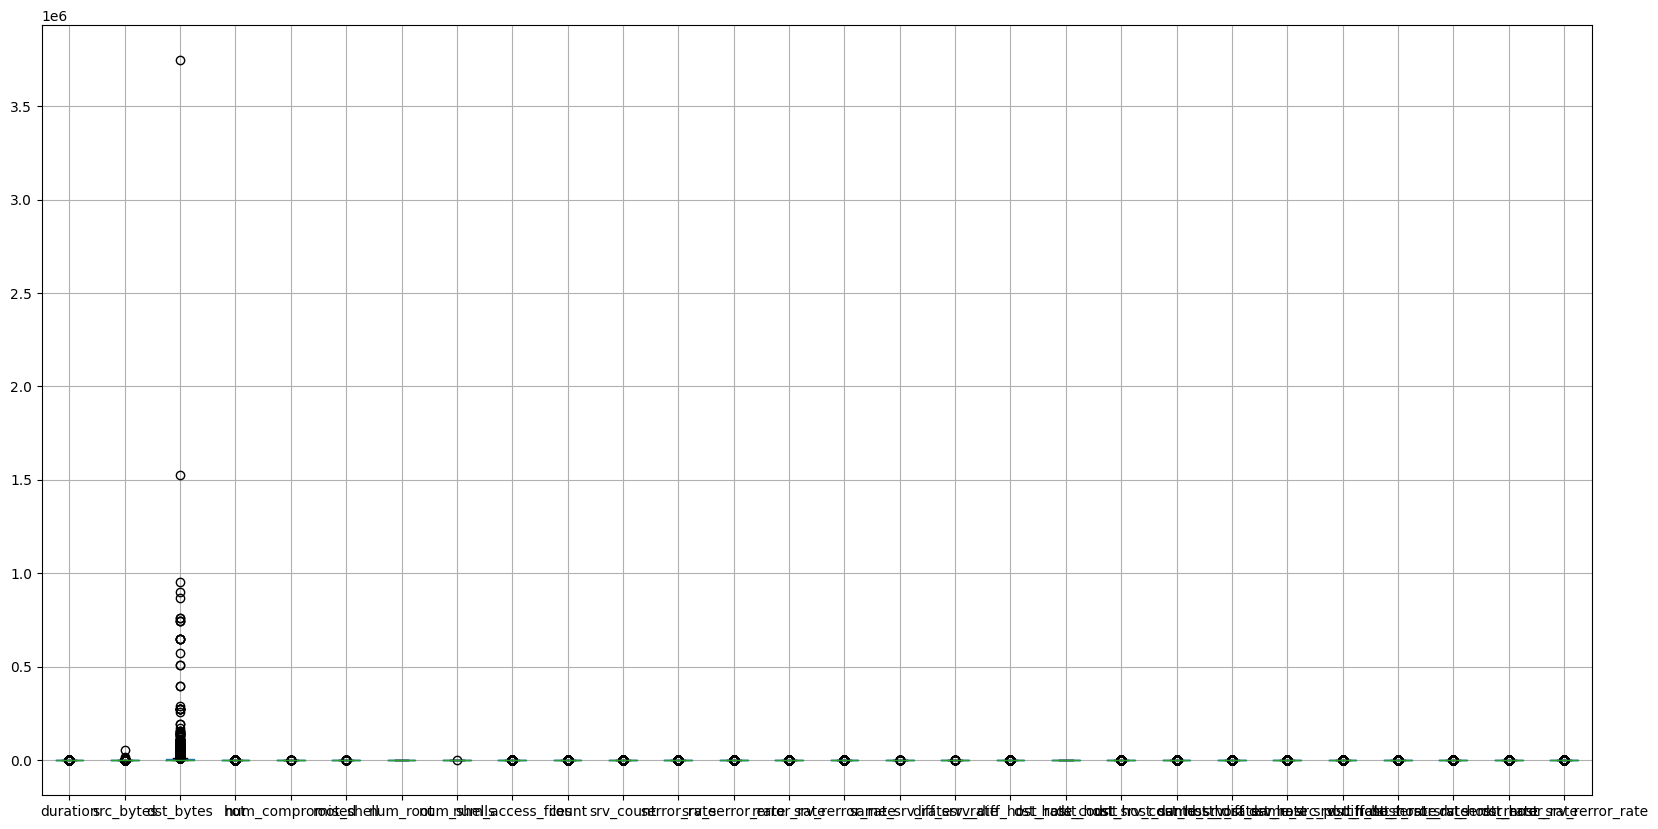

In [18]:
df_http_normal.boxplot(figsize=(20, 10))
plt.show()

In [19]:
# scaling the data using standard scaler
scaler = StandardScaler()
df_http_normal = pd.DataFrame(scaler.fit_transform(df_http_normal), columns=df_http_normal.columns)

In [20]:
# reducing the dimensionality of the data using PCA and covering 80% of the variance in the original data
pca = PCA(n_components=0.8)
pca.fit(df_http_normal)

PCA(n_components=0.8)

In [21]:
pca_cols = ['PCA_'+ str(i) for i in range(pca.n_components_)]
df_pca = pd.DataFrame(pca.transform(df_http_normal), columns=pca_cols)

In [22]:
df_pca.head()

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,PCA_10,PCA_11,PCA_12,PCA_13
0,-0.060903,3.058827,-0.106889,0.604668,-0.468816,-0.050319,-0.078120,0.137547,0.388254,0.092866,-0.237951,-0.541847,0.223068,-0.395619
1,-1.586495,-1.048621,-0.591000,1.457358,0.132486,-0.914245,-0.713256,-0.064359,-0.088131,-0.003905,0.161644,0.374199,-0.394063,0.285573
2,0.164215,0.323162,0.543685,-0.913604,-0.240538,1.020474,0.147204,-0.158811,-0.354402,-0.185615,0.035312,0.322875,-0.497734,0.926664
3,-0.520785,0.637181,0.178747,-0.075614,-0.025594,-0.028388,0.447429,0.147918,-0.181066,-0.079998,-0.018573,-0.051630,0.040788,0.413889
4,-0.315955,0.046296,0.467739,-0.565489,-0.191717,0.384804,0.311983,0.030976,-0.086645,-0.012260,-0.077344,-0.318579,0.274779,-0.639200


In [23]:
def get_windows(df, window_size=20, stride=10):
  windows_arr = []
  for i in tqdm.tqdm(range(0, len(df)-window_size+1, stride)):
    windows_arr.append(df.iloc[i:i+window_size, :].to_numpy())
  return np.array(windows_arr)

In [24]:
window_size, stride = 10, 10
windows_arr = get_windows(df_pca, window_size, stride)

100%|██████████| 3804/3804 [00:00<00:00, 20636.37it/s]


In [25]:
# shuffling windows for training purpose
indices = np.arange(windows_arr.shape[0])
np.random.shuffle(indices)
windows_shuffled = windows_arr[indices]

In [27]:
# Clear previous session
K.clear_session()

# Get number of features dynamically
n_features = int(pca.n_components_)

# -----------------------
# Encoder
# -----------------------
encoder = Sequential([
    LSTM(
        80,
        return_sequences=True,
        activation='selu',
        input_shape=(window_size, n_features),
        dropout=0.2,
        recurrent_dropout=0.2
    ),
    LSTM(
        50,
        activation='selu',
        return_sequences=True,
        dropout=0.2,
        recurrent_dropout=0.2
    ),
    LSTM(
        20,
        activation='selu',
        dropout=0.2,
        recurrent_dropout=0.2
    )
], name='encoder')

# -----------------------
# Decoder
# -----------------------
decoder = Sequential([
    RepeatVector(window_size),
    LSTM(50, return_sequences=True, activation='selu', dropout=0.2, recurrent_dropout=0.2),
    LSTM(80, return_sequences=True, activation='selu', dropout=0.2, recurrent_dropout=0.2),
    TimeDistributed(Dense(int(n_features), activation='linear'))
], name='decoder')

# -----------------------
# Autoencoder
# -----------------------
autoencoder = Sequential([
    encoder,
    decoder
], name='autoencoder')

# Compile
autoencoder.compile(
    optimizer='adam',
    loss=tf.keras.losses.Huber(1.0)
)

# Summary
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 20)             │        62,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 10, 14)         │        57,254 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,534 (466.93 KB)

 Trainable params: 119,534 (466.93 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
encoder.summary(), decoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 80)         │        30,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 50)         │        26,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 20)             │         5,680 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,280 (243.28 KB)

 Trainable params: 62,280 (243.28 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ repeat_vector (RepeatVector)    │ (None, 10, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 10, 50)         │        14,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 10, 80)         │        41,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 14)         │         1,134 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,254 (223.65 KB)

 Trainable params: 57,254 (223.65 KB)

 Non-trainable params: 0 (0.00 B)

(None, None)

In [29]:
check_point = tf.keras.callbacks.ModelCheckpoint('autoencoder.h5', monitor='val_loss', save_best_only=True, mode='min', verbose=1)
train_hist = autoencoder.fit(windows_shuffled, windows_shuffled, batch_size=64, validation_split=0.2, epochs=50, callbacks=[check_point])

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.2566
Epoch 1: val_loss improved from None to 0.25906, saving model to autoencoder.h5



Epoch 1: finished saving model to autoencoder.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 24s 111ms/step - loss: 0.2549 - val_loss: 0.2591
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.2439
Epoch 2: val_loss improved from 0.25906 to 0.25538, saving model to autoencoder.h5



Epoch 2: finished saving model to autoencoder.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.2476 - val_loss: 0.2554
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.2496
Epoch 3: val_loss improved from 0.25538 to 0.25277, saving model to autoencoder.h5



Epoch 3: finished saving model to autoencoder.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.2470 - val_loss: 0.2528
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.2469
Epoch 4: val_loss improved from 0.25277 to 0.25078, saving model to autoencoder.h5



Epoch 4: finished saving model to autoencoder.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 0.2432 - val_loss: 0.2508
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.2472
Epoch 5: val_loss improved from 0.25078 to 0.24945, saving model to autoencoder.h5


...


Epoch 43: finished saving model to autoencoder.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 0.2292 - val_loss: 0.2324
Epoch 44/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.2237
Epoch 44: val_loss did not improve from 0.23239
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.2289 - val_loss: 0.2326
Epoch 45/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.2290
Epoch 45: val_loss did not improve from 0.23239
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.2281 - val_loss: 0.2325
Epoch 46/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.2363
Epoch 46: val_loss improved from 0.23239 to 0.23180, saving model to autoencoder.h5



Epoch 46: finished saving model to autoencoder.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.2286 - val_loss: 0.2318
Epoch 47/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.2298
Epoch 47: val_loss did not improve from 0.23180
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.2276 - val_loss: 0.2318
Epoch 48/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.2300
Epoch 48: val_loss improved from 0.23180 to 0.23155, saving model to autoencoder.h5



Epoch 48: finished saving model to autoencoder.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 0.2284 - val_loss: 0.2316
Epoch 49/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.2290
Epoch 49: val_loss improved from 0.23155 to 0.23138, saving model to autoencoder.h5



Epoch 49: finished saving model to autoencoder.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.2277 - val_loss: 0.2314
Epoch 50/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.2261
Epoch 50: val_loss improved from 0.23138 to 0.23090, saving model to autoencoder.h5



Epoch 50: finished saving model to autoencoder.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 0.2271 - val_loss: 0.2309


In [30]:
autoencoder_loaded = tf.keras.models.load_model('autoencoder.h5')

In [32]:
# loading the test dataframe
test_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,private,REJ,0,0,0,0,0,0,...,10,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune
1,0,tcp,private,REJ,0,0,0,0,0,0,...,1,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,86,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,57,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,86,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan


In [33]:
# slicing only the rows belonging to http service
test_df_http = test_df[test_df['service']=='http']

In [34]:
# binary indicator to represent anomalies
status = pd.Series([0 if i=='normal' else 1 for i in test_df_http['label']])
test_labels = [1 if np.sum(status[i:i+window_size])>0 else 0 for i in range(0, len(status)-window_size+1, stride)]

In [35]:
# dropping catrgorical columns
test_df_http.drop(['protocol_type', 'service', 'flag', 'land', 'logged_in', 'is_host_login', 'is_guest_login', 'label'], axis=1, inplace=True)
# dropping columns with no std deviation
test_df_http.drop(['wrong_fragment', 'urgent', 'num_failed_logins', 'su_attempted', 'num_file_creations', 'num_outbound_cmds'], axis=1, inplace=True)

/tmp/ipykernel_3510/445517313.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df_http.drop(['protocol_type', 'service', 'flag', 'land', 'logged_in', 'is_host_login', 'is_guest_login', 'label'], axis=1, inplace=True)
/tmp/ipykernel_3510/445517313.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df_http.drop(['wrong_fragment', 'urgent', 'num_failed_logins', 'su_attempted', 'num_file_creations', 'num_outbound_cmds'], axis=1, inplace=True)


In [36]:
test_df_http = pd.DataFrame(scaler.transform(test_df_http), columns=test_df_http.columns)

In [37]:
test_df_http_pca = pd.DataFrame(pca.transform(test_df_http), columns=pca_cols)
test_df_http_pca.head()

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,PCA_10,PCA_11,PCA_12,PCA_13
0,-0.572331,0.050902,0.267721,-0.422568,-0.000086,0.027162,0.411679,0.266077,0.112815,0.029745,-0.160190,-0.449429,0.318125,-0.473759
1,-1.460099,-1.163590,-0.475768,1.921642,0.156978,-0.575349,-1.717355,-0.081136,-0.298666,-0.030223,0.436130,0.779961,0.067423,0.487826
2,-0.460166,-0.096301,0.362950,-0.244841,-0.085281,0.351668,-0.037155,0.018753,-0.059105,-0.004037,-0.023376,-0.220198,0.536313,-0.328307
3,-1.461138,-0.861283,-0.457365,1.033600,0.079798,-0.810676,-0.397341,-0.026224,0.038237,0.038567,0.035129,0.038150,-0.122146,-0.152248
4,-0.451162,-0.275738,0.269867,0.300232,-0.077401,0.421520,-0.599548,0.072179,-0.289217,-0.040810,0.179048,0.205191,0.286521,-0.371016


In [38]:
test_windows = get_windows(test_df_http_pca, window_size=10, stride=10)

100%|██████████| 785/785 [00:00<00:00, 19145.28it/s]


In [39]:
test_windows_pred = autoencoder_loaded.predict(test_windows)

25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 227ms/step


In [40]:
# # calculating reconstruction error for each sample
# # implemented in tensorflow for faster execution when gpu is available

# def get_recon_erros(true_windows, pred_windows):
#   recon_errors = []

#   def cond(y_true, y_pred, i, iters):
#     return tf.less(i, iters)

#   def body(y_true, y_pred, i, iters):
#     tensor_for_error = tf.math.subtract(tf.slice(y_true, [i, 0, 0], [1, -1, -1]), tf.slice(y_pred, [i, 0, 0], [1, -1, -1]))
#     tensor_for_error = tf.reshape(tensor_for_error, [window_size, pca.n_components_])
#     recon_error = tf.math.reduce_mean(tf.norm(tensor_for_error, ord='euclidean', axis=1))
#     # this is the list initialized above
#     recon_errors.append(recon_error.numpy())
#     return [y_true, y_pred, tf.add(i, 1), iters]

#   iters = tf.constant(len(true_windows))

#   label = tf.while_loop(cond, body, [tf.constant(true_windows.astype(np.float32)), tf.constant(pred_windows.astype(np.float32)), 0, iters])
#   return recon_errors
def get_recon_errors(true_windows, pred_windows):
    return np.mean(
        np.linalg.norm(true_windows - pred_windows, axis=2),
        axis=1
    )

In [41]:
# recon_errors = get_recon_erros(test_windows, test_windows_pred)
# recon_errors = np.array(recon_errors).reshape(-1, 1)
recon_errors = get_recon_errors(test_windows, test_windows_pred)
recon_errors = recon_errors.reshape(-1, 1)
# scaling the reconstruction errors set to [0, 1] scale
mm_scaler = MinMaxScaler()
anomaly_scores = mm_scaler.fit_transform(recon_errors).flatten()

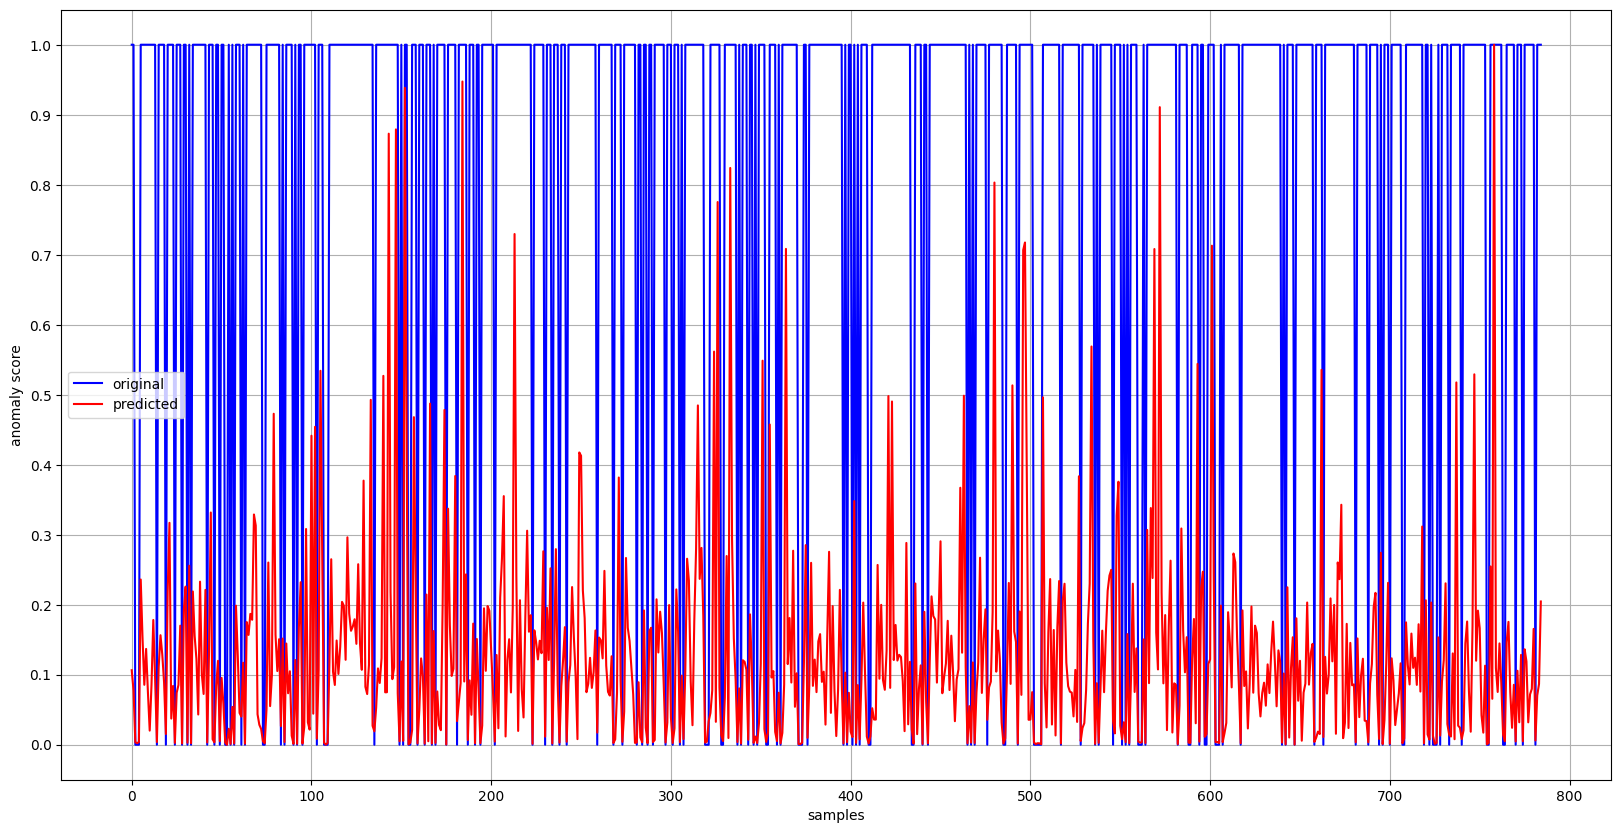

In [42]:
plt.figure(figsize=(20, 10))
plt.plot(test_labels, c='blue', label='original')
plt.plot(anomaly_scores, c='red', label='predicted')
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlabel('samples')
plt.ylabel('anomaly score')
plt.grid()
plt.legend()
plt.show()

In [43]:
fpr, tpr, thresholds = roc_curve(test_labels, anomaly_scores)
auc = roc_auc_score(test_labels, anomaly_scores)
print('Area under ROC curve: {}'.format(auc))

Area under ROC curve: 0.990024442726722


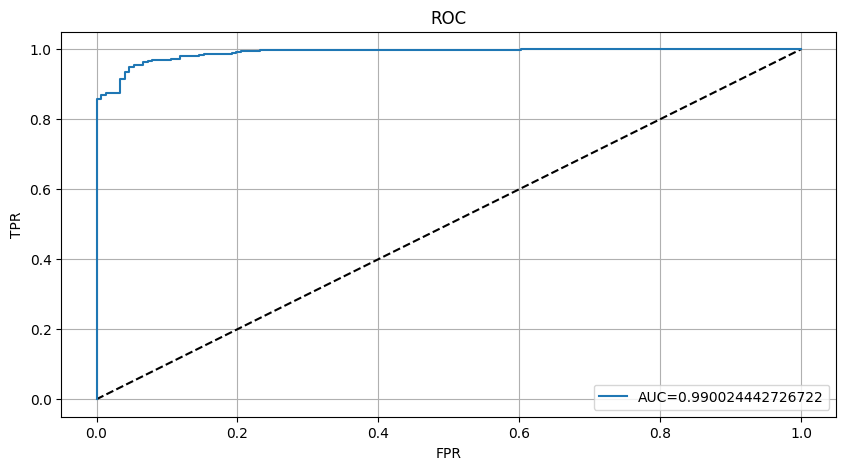

In [44]:
plt.figure(figsize=(10,5))
plt.plot([0, 1], [0, 1], color = 'black', linestyle='--')
plt.plot(fpr, tpr, label='AUC={}'.format(auc))
plt.grid()
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.title('ROC')
plt.show()

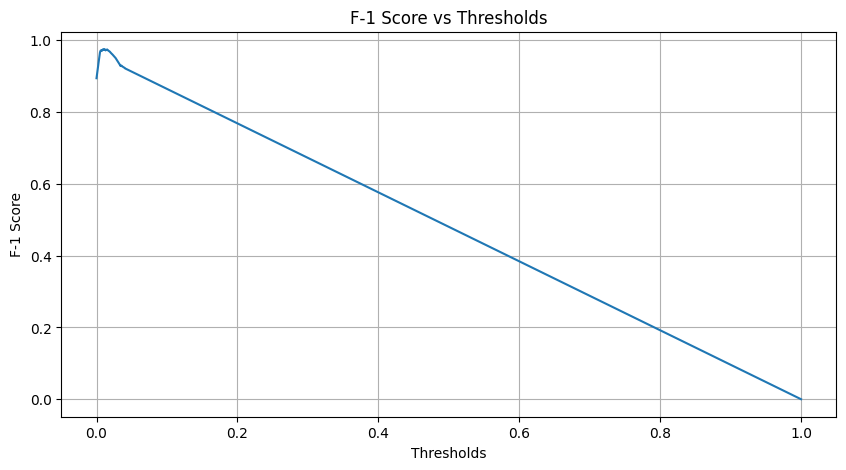

In [45]:
anomaly_combinations = [(anomaly_scores>i).astype(np.int32) for i in thresholds]
f1_scores = [f1_score(test_labels, i) for i in anomaly_combinations]
plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores)
plt.grid()
plt.xlabel('Thresholds')
plt.ylabel('F-1 Score')
plt.title('F-1 Score vs Thresholds')
plt.show()

In [46]:
max_f1_score = np.max(f1_scores)
best_threshold = thresholds[f1_scores.index(max_f1_score)]
print('best threshold = {}'.format(best_threshold))

best threshold = 0.009347647921217402


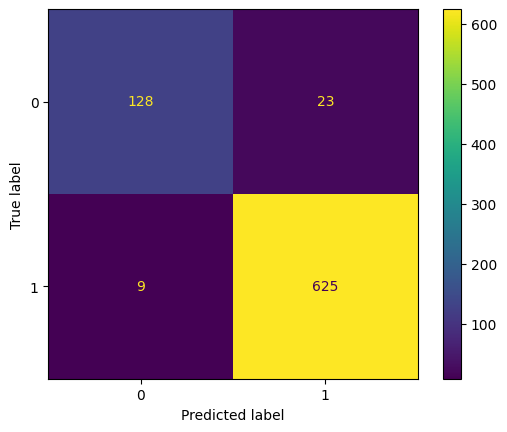

In [47]:
anomaly_indicator = (anomaly_scores>best_threshold).astype(np.int32)
# confusion_matrix(test_labels, anomaly_indicator)
ConfusionMatrixDisplay.from_predictions(test_labels, anomaly_indicator)
plt.show()

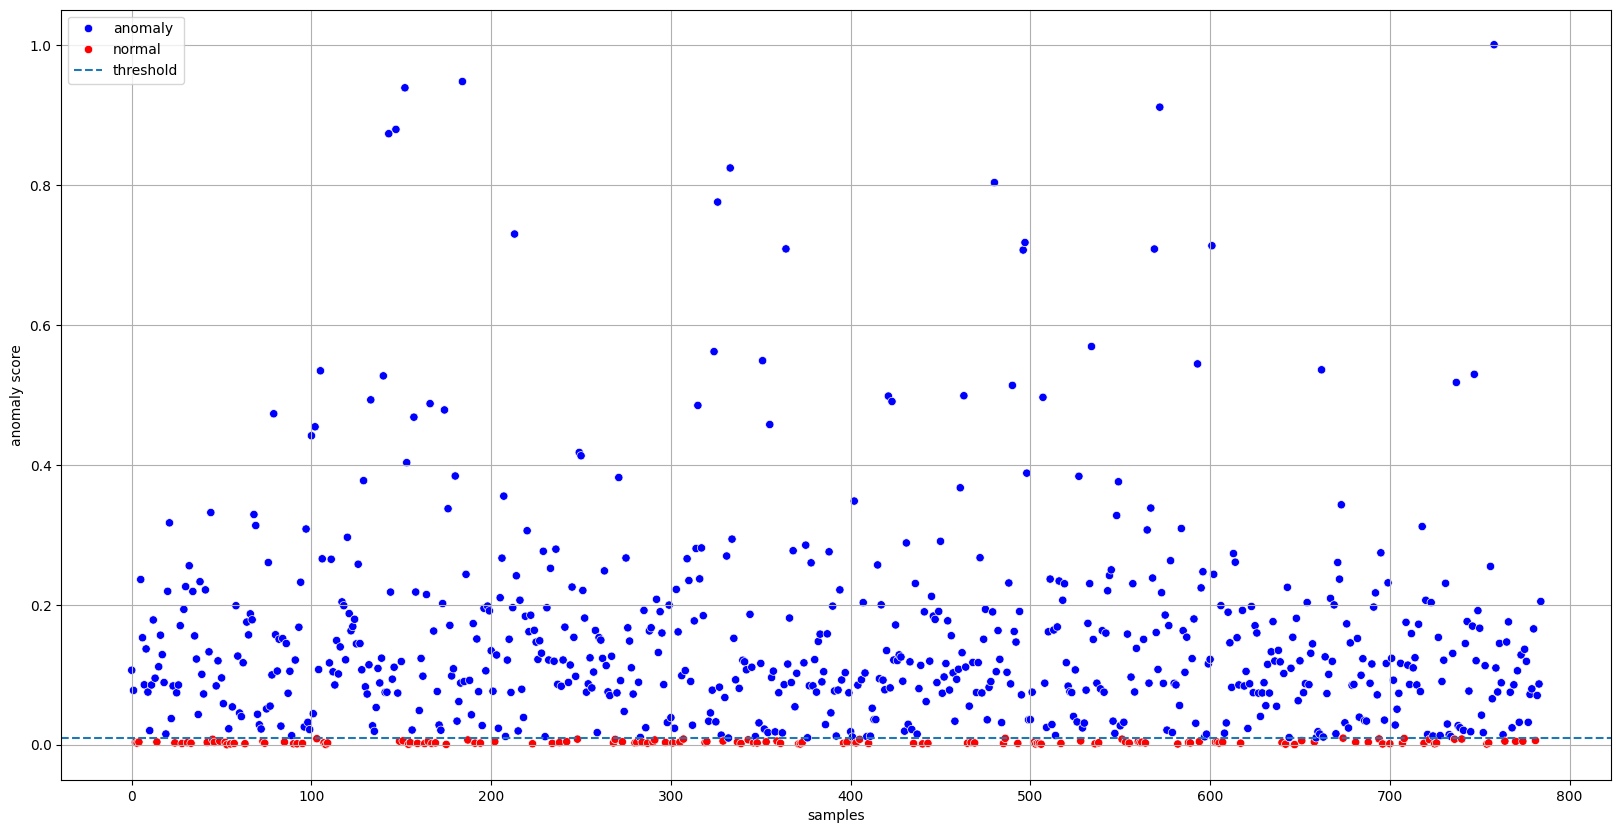

In [48]:
plt.figure(figsize=(20,10))
sns.scatterplot(x=np.arange(0, len(anomaly_scores)), y= anomaly_scores, hue=['normal' if i==0 else 'anomaly' for i in anomaly_indicator],
                palette=['blue', 'red'], legend='full')
plt.axhline(y = best_threshold, linestyle='--', label='threshold')
plt.xlabel('samples')
plt.ylabel('anomaly score')
plt.legend()
plt.grid()
plt.show()

In [49]:
precision = precision_score(test_labels, anomaly_indicator)
recall = recall_score(test_labels, anomaly_indicator)
f1_sc = f1_score(test_labels, anomaly_indicator)
accuracy_sc = accuracy_score(test_labels, anomaly_indicator)
print('Model has the following classification metrics:\n precision = {}\n recall = {}\n f1_score = {}\n accuracy_score = {}'
      .format(precision, recall, f1_sc, accuracy_sc))

Model has the following classification metrics:
 precision = 0.9645061728395061
 recall = 0.9858044164037855
 f1_score = 0.9750390015600624
 accuracy_score = 0.9592356687898089
